In [7]:
import pandas as pd
import numpy as np
from utils.plots import plot_spectrum

# Tratar dados de espectro de energia

## Carregar dados do TXT

In [8]:
data = {'energy': [], 'intensity': []}

with open("../ContinuousSpectrumFileRaw.txt", "r", encoding="utf-8") as fd:
    for i in range(18):
        fd.readline()  # Pula as linhas de cabeçalho

    lines = fd.readlines()  # Lê o restante das linhas

    for line in lines:
        values = line.split()
        energy = float(values[0])
        intensity = float(values[1])
        data['energy'].append(energy)
        data['intensity'].append(intensity)

df = pd.DataFrame(data)
df.head()

,energy,intensity
0,1.5,0.000000e+00
1,2.5,8.743012e-236
2,3.5,7.359360e-93
3,4.5,2.009053e-43
4,5.5,6.342836e-22


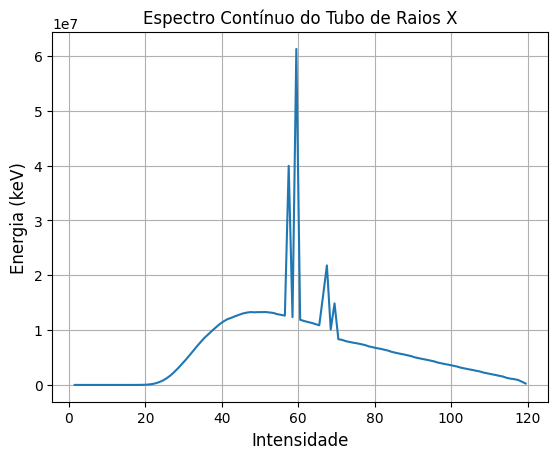

In [9]:
plot_spectrum(df['energy'], df['intensity'], title='Espectro Contínuo do Tubo de Raios X')

## Normalizar dados

In [10]:
sum_intensity = np.sum(df['intensity'])
print(f"Sum of Intensities: {sum_intensity}")

df['intensity_normalized'] = (df['intensity'] / sum_intensity)
df['intensity_normalized'] = df['intensity_normalized'] * 1e10

sum_intensity_normalized = np.sum(df['intensity_normalized'])
print(f"Sum of Normalized Intensities: {sum_intensity_normalized}")

df.head()

Sum of Intensities: 777400161.3499397
Sum of Normalized Intensities: 10000000000.000002


,energy,intensity,intensity_normalized
0,1.5,0.000000e+00,0.000000e+00
1,2.5,8.743012e-236,1.124648e-234
2,3.5,7.359360e-93,9.466631e-92
3,4.5,2.009053e-43,2.584323e-42
4,5.5,6.342836e-22,8.159036e-21


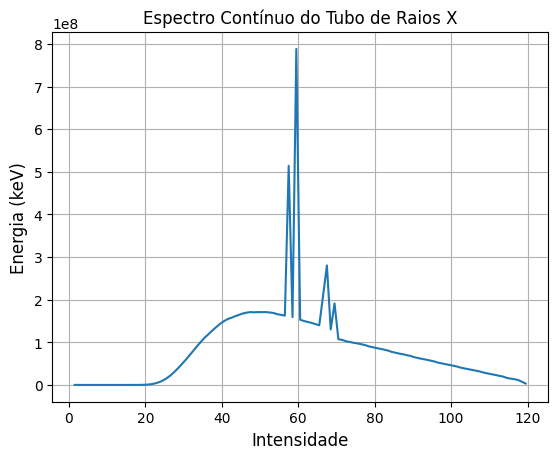

In [11]:
plot_spectrum(df['energy'], df['intensity_normalized'], title='Espectro Contínuo do Tubo de Raios X')

## Salvar os dados

In [12]:
with open("../ContinuousSpectrumFile.txt", "w", encoding="utf-8") as fd:
    # fd.write("# Energy (keV)\tIntensity (a.u.)\n")
    fd.write("0.5 0.0\n")  # Adiciona o ponto inicial
    for index, row in df.iterrows():
        fd.write(f"{row['energy']} {row['intensity_normalized']}\n")